In [1]:
import torch as t
import torch.nn as nn
import torch.nn.functional as F
from typing import Annotated

class PPO(nn.Module):
  def __init__(self, n_actions: int, d_state: int, lr=7e-4, device="cuda"):
    super().__init__()

    self._n_actions = n_actions
    self._d_state = d_state
    self.device = device

    self.policy = nn.Sequential(
      nn.Linear(d_state, 32),
      nn.ReLU(),
      nn.Linear(32, 32),
      nn.ReLU(),
      nn.Linear(32, n_actions)
    )

    self.critic = nn.Sequential(
      nn.Linear(d_state, 32),
      nn.ReLU(),
      nn.Linear(32, 32),
      nn.ReLU(),
      nn.Linear(32, 1)
    )

    self.policy_optim = t.optim.Adam(self.policy.parameters(), lr=lr)
    self.critic_optim = t.optim.Adam(self.critic.parameters(), lr=lr)

  def forward(self, obs: Annotated[t.Tensor, "n_envs obs_shape"]):
    action_logits = self.policy(obs)
    state_values = self.critic(obs)

    return action_logits, state_values


  def select_action(self, obs: Annotated[t.Tensor, "n_envs obs_shape"]) -> tuple[
    Annotated[t.Tensor, "n_envs"],
    Annotated[t.Tensor, "n_envs"],
    Annotated[t.Tensor, "n_envs"],
  ]:
    action_logits, state_values = self.forward(obs)
    action_dist = t.distributions.Categorical(logits=action_logits)
    actions = action_dist.sample()
    action_log_probs = action_dist.log_prob(actions)

    return actions, action_log_probs, state_values

  def evaluate(self, obs: Annotated[t.Tensor, "minibatch_size obs_shape"], actions: Annotated[t.Tensor, "minibatch_size"]):
    action_logits, state_values = self.forward(obs)
    action_dist = t.distributions.Categorical(logits=action_logits)
    action_log_probs = action_dist.log_prob(actions)

    return action_log_probs, state_values, action_dist.entropy()


  def update_params(self, policy_loss: t.Tensor, critic_loss: t.Tensor):    
    self.policy_optim.zero_grad()
    self.critic_optim.zero_grad()

    policy_loss.backward()
    critic_loss.backward()

    nn.utils.clip_grad_norm_(self.policy.parameters(), 0.5)
    nn.utils.clip_grad_norm_(self.critic.parameters(), 0.5)

    self.policy_optim.step()
    self.critic_optim.step()

In [2]:
import gymnasium as gym

# Initialise the environment
n_envs = 8
n_updates = 5000
n_rollout = 10
device = "cuda"

envs = gym.make_vec("LunarLander-v3", num_envs=n_envs, max_episode_steps=600,
                    continuous=False, gravity=-10.0, enable_wind=False,
                    wind_power=15.0, turbulence_power=1.5)

envs_wrapper = gym.wrappers.vector.RecordEpisodeStatistics(
  envs, buffer_length=n_envs*n_updates
)

obs_shape = int(envs.single_observation_space.shape[0])
action_shape = int(envs.single_action_space.n)

In [3]:
from tqdm import tqdm
from einops import rearrange
import numpy as np

ppo = PPO(n_actions=action_shape, d_state=obs_shape).to(device)
df = 0.99
lam = 0.95
ent_coef = 0.01
n_epochs = 5
mb_size = 8
eps = 0.2

obs, info = envs.reset()
obs = t.tensor(obs, dtype=t.float32, device=device)

pbar = tqdm(range(n_updates))
for update in pbar:
  ep_obs = t.zeros(n_rollout, n_envs, obs_shape, device=device)
  ep_state_values = t.zeros(n_rollout, n_envs, device=device)
  ep_actions = t.zeros(n_rollout, n_envs, device=device, dtype=t.long)
  ep_action_log_probs = t.zeros(n_rollout, n_envs, device=device)
  ep_rewards = t.zeros(n_rollout, n_envs, device=device)
  masks = t.zeros(n_rollout, n_envs, device=device)

  with t.no_grad():
    for step in range(n_rollout):
      actions, action_log_probs, state_values = ppo.select_action(obs)

      states, rewards, terminated, truncated, infos = envs_wrapper.step(actions.cpu().numpy())


      ep_obs[step] = obs
      ep_state_values[step] = state_values.squeeze()
      ep_rewards[step] = t.tensor(rewards, device=device)
      ep_actions[step] = actions
      ep_action_log_probs[step] = action_log_probs
      
      masks[step] = t.tensor(~(terminated | truncated), dtype=t.float32, device=device)
      obs = t.tensor(states, dtype=t.float32, device=device)

      if truncated.any():
        with t.no_grad():
          ep_rewards[step] += df * ppo.critic(obs).squeeze(-1) * t.tensor(truncated, dtype=t.float32, device=device)

    v_T = ppo.critic(obs).squeeze(-1)

  advantages = t.zeros(n_rollout, n_envs, device=device)
  next_value, next_adv = v_T, 0
  for i in reversed(range(n_rollout)):
    delta = ep_rewards[i] + df * next_value * masks[i] - ep_state_values[i]
    advantages[i] = delta + df * lam * next_adv * masks[i]
    next_value, next_adv = ep_state_values[i], advantages[i]

  # flatten
  b_obs = rearrange(ep_obs, "nr ne d -> (nr ne) d")
  b_actions = rearrange(ep_actions, "nr ne -> (nr ne)")
  b_action_log_probs = rearrange(ep_action_log_probs, "nr ne -> (nr ne)")
  b_state_values = rearrange(ep_state_values, "nr ne -> (nr ne)")
  b_advantages = rearrange(advantages, "nr ne -> (nr ne)")
  b_returns  = b_advantages + b_state_values

  batch_size = n_rollout * n_envs
  b_inds = np.arange(batch_size)
  
  for epoch in range(n_epochs):
    np.random.shuffle(b_inds)
    
    for start in range(0, batch_size, mb_size):
      mb = b_inds[start:start+mb_size]

      mb_adv = b_advantages[mb]
      mb_adv = (mb_adv - mb_adv.mean()) / (mb_adv.std() + 1e-8)

      new_log_policy, new_state_values, entropy = ppo.evaluate(b_obs[mb], b_actions[mb])
      r = t.exp(new_log_policy - b_action_log_probs[mb])

      unclipped = r*mb_adv
      clipped   = t.clamp(r, 1 - eps, 1 + eps) * mb_adv

      policy_loss = -t.min(unclipped, clipped).mean() - ent_coef * entropy.mean()
      critic_loss = F.mse_loss(new_state_values.squeeze(), b_returns[mb])

      ppo.update_params(policy_loss, critic_loss)

      if len(envs_wrapper.return_queue) > 0:
        recent = np.array(envs_wrapper.return_queue)[-100:]
        pbar.set_postfix(
          ret=f"{recent.mean():.1f}",
          len=f"{np.array(envs_wrapper.length_queue)[-100:].mean():.0f}",
          ploss=f"{policy_loss.item():.3f}",
          closs=f"{critic_loss.item():.3f}",
          refresh=False,
        )


100%|██████████| 5000/5000 [18:07<00:00,  4.60it/s, closs=0.591, len=299, ploss=-0.055, ret=148.8]   


In [15]:
env = gym.make("LunarLander-v3", render_mode="human", max_episode_steps=600,
                    continuous=False, gravity=-10.0, enable_wind=False,
                    wind_power=15.0, turbulence_power=1.5)

obs, info = env.reset()
obs = t.tensor(obs, device=device).unsqueeze(0)

total_reward = 0.
done = False
while not done:
  with t.no_grad():
    logits = ppo.policy(obs)
    action = logits.argmax(dim=-1)
  next_obs, reward, terminated, truncated, info = env.step(action.item())
  total_reward += float(reward)
  obs = t.tensor(next_obs, device=device).unsqueeze(0)

  done = terminated or truncated

  if done:
    break

env.close()

total_reward

267.03845807181244

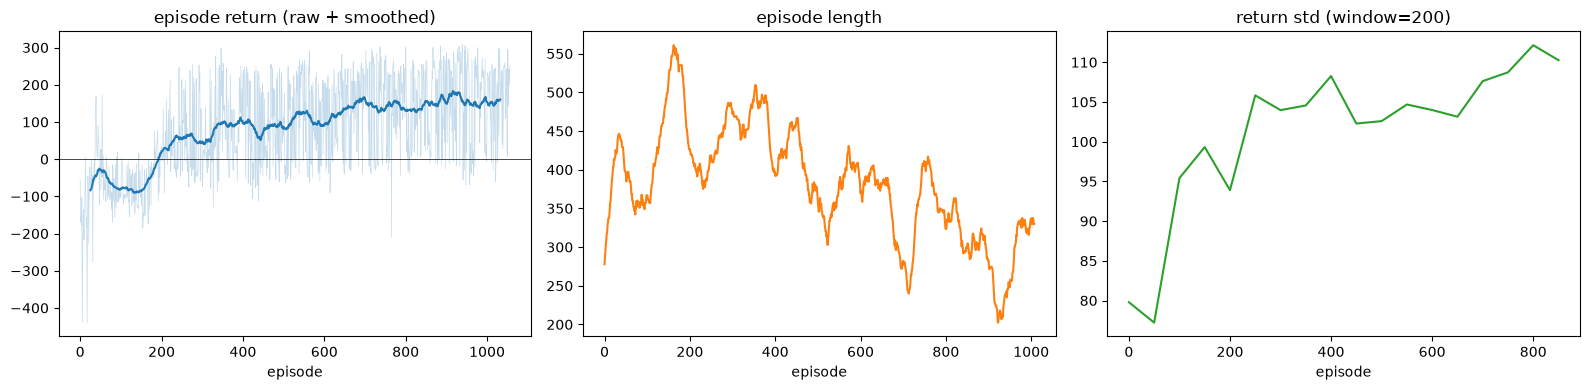

episodes: 1057
peak smoothed: 183.3
last-100 mean: 148.8  std: 105.5


In [5]:
import numpy as np
import matplotlib.pyplot as plt

returns = np.array(envs_wrapper.return_queue).flatten()
lengths = np.array(envs_wrapper.length_queue).flatten()

def smooth(x, w=50):
    return np.convolve(x, np.ones(w) / w, mode="valid") if len(x) >= w else x

fig, ax = plt.subplots(1, 3, figsize=(16, 4))

ax[0].plot(returns, alpha=0.25, lw=0.5, color="tab:blue")
ax[0].plot(np.arange(len(smooth(returns))) + 25, smooth(returns), color="tab:blue")
ax[0].axhline(0, color="k", lw=0.5)
ax[0].set_title("episode return (raw + smoothed)")
ax[0].set_xlabel("episode")

ax[1].plot(smooth(lengths), color="tab:orange")
ax[1].set_title("episode length")
ax[1].set_xlabel("episode")

w = 200
stds = [returns[i:i+w].std() for i in range(0, len(returns) - w, w // 4)]
ax[2].plot(np.arange(len(stds)) * (w // 4), stds, color="tab:green")
ax[2].set_title(f"return std (window={w})")
ax[2].set_xlabel("episode")

plt.tight_layout()
plt.show()

print(f"episodes: {len(returns)}")
print(f"peak smoothed: {smooth(returns).max():.1f}")
print(f"last-100 mean: {returns[-100:].mean():.1f}  std: {returns[-100:].std():.1f}")